<a href="https://colab.research.google.com/github/IshikaGarg787/ML-Assignment/blob/main/Consumer_Shopping_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv("/content/Consumer_Shopping_Trends_2026 (6).csv")

In [ ]:
data.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [ ]:
data.shape

(11789, 25)

In [ ]:
data.isnull().sum()

,0
age,0
monthly_income,0
daily_internet_hours,0
smartphone_usage_years,0
social_media_hours,0
online_payment_trust_score,0
tech_savvy_score,0
monthly_online_orders,0
monthly_store_visits,0
avg_online_spend,0


In [ ]:
#Checking if data is balanced or imbalanced
data['shopping_preference'].value_counts()

,count
shopping_preference,
Store,10244
Online,1176
Hybrid,369


In [ ]:
x = data.drop(columns=['shopping_preference'])
y = data['shopping_preference']

In [ ]:
#Encoding for target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
#One-Hot Encoding for Categorical Features
x =pd.get_dummies(x, drop_first = True)

In [ ]:
#Train-Test-Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)

In [ ]:
#Applying smote to handle class imbalance
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# x_train, y_train = smote.fit_resample(x_train, y_train)

In [ ]:
#Checking if data is now balanced or not
import collections
print(collections.Counter(y_train))

Counter({np.int64(2): 8195, np.int64(1): 941, np.int64(0): 295})


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(9431, 26)
(2358, 26)


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_test, y_pred, title):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Logistic Regression

In [ ]:
#Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

In [ ]:
#Accuracy of Logistic Regression
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.981340118744699
              precision    recall  f1-score   support

           0       0.92      0.45      0.60        74
           1       0.94      0.99      0.97       235
           2       0.99      1.00      0.99      2049

    accuracy                           0.98      2358
   macro avg       0.95      0.81      0.85      2358
weighted avg       0.98      0.98      0.98      2358



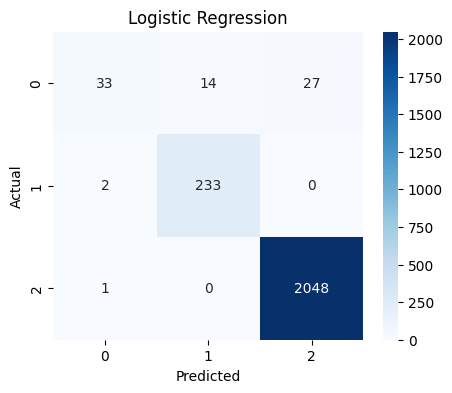

In [ ]:
plot_cm(y_test, y_pred_lr, "Logistic Regression")

Random Forest

In [ ]:
#Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [ ]:
#Accuracy of Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9567430025445293
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.88      0.91      0.89       235
           2       0.97      1.00      0.98      2049

    accuracy                           0.96      2358
   macro avg       0.62      0.63      0.62      2358
weighted avg       0.93      0.96      0.94      2358



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


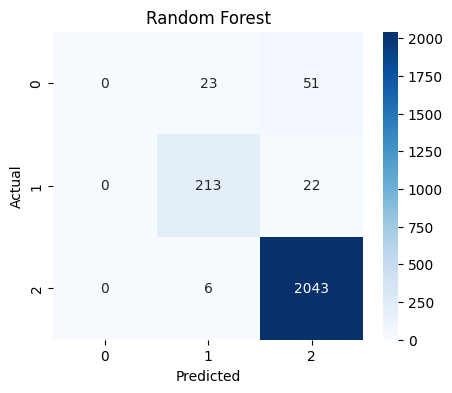

In [ ]:
plot_cm(y_test, y_pred_rf, "Random Forest")

XGBoost

In [ ]:
#Model 3: XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

In [ ]:
#Accuracy of XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9673452078032231
              precision    recall  f1-score   support

           0       0.52      0.20      0.29        74
           1       0.90      0.95      0.92       235
           2       0.98      1.00      0.99      2049

    accuracy                           0.97      2358
   macro avg       0.80      0.72      0.73      2358
weighted avg       0.96      0.97      0.96      2358



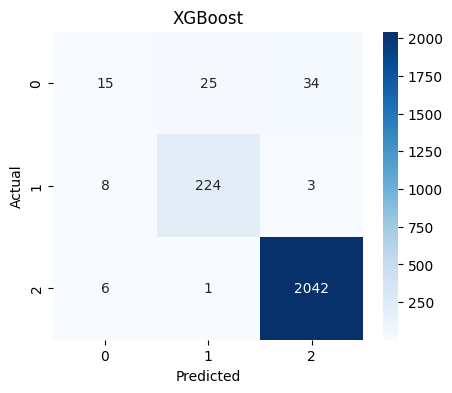

In [ ]:
plot_cm(y_test, y_pred_xgb, "XGBoost")

Decision Tree

In [ ]:
#Model 4: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

In [ ]:
#Accuracy of Decision Tree
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9223918575063613
              precision    recall  f1-score   support

           0       0.19      0.19      0.19        74
           1       0.74      0.77      0.75       235
           2       0.97      0.97      0.97      2049

    accuracy                           0.92      2358
   macro avg       0.63      0.64      0.64      2358
weighted avg       0.92      0.92      0.92      2358



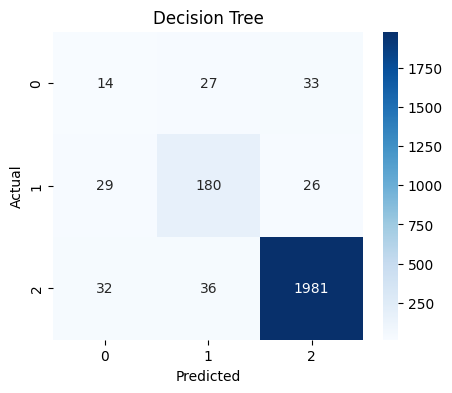

In [ ]:
plot_cm(y_test, y_pred_dt, "Decision Tree")

SVM

In [ ]:
#Model 5: SVM
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)

In [ ]:
#Accuracy of SVM
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.955470737913486
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.90      0.89      0.89       235
           2       0.96      1.00      0.98      2049

    accuracy                           0.96      2358
   macro avg       0.62      0.63      0.62      2358
weighted avg       0.93      0.96      0.94      2358



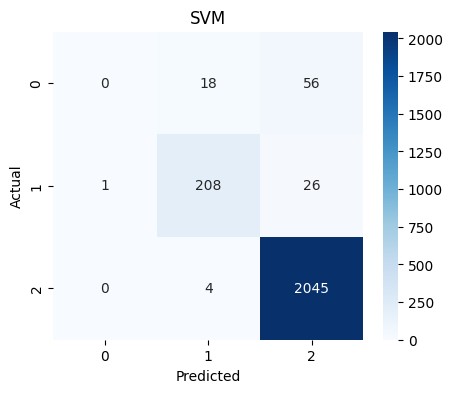

In [ ]:
plot_cm(y_test, y_pred_svm, "SVM")

## Final Conclusion

Among all the models tested, Logistic Regression achieved the highest accuracy. Considering overall performance and ability to handle complex patterns, Logistic Regression is chosen as the best model. The model performs strongly on major classes, but the Hybrid class remains the most challenging to predict, indicating overlapping customer behavior.
